# Decision Tress and Random Forest

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv(r"C:\Users\kulso\OneDrive\Desktop\heart.csv")

In [4]:
X = df.drop('target',axis=1) #feature
y = df['target']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y, random_state=42)

Train a decision tree

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

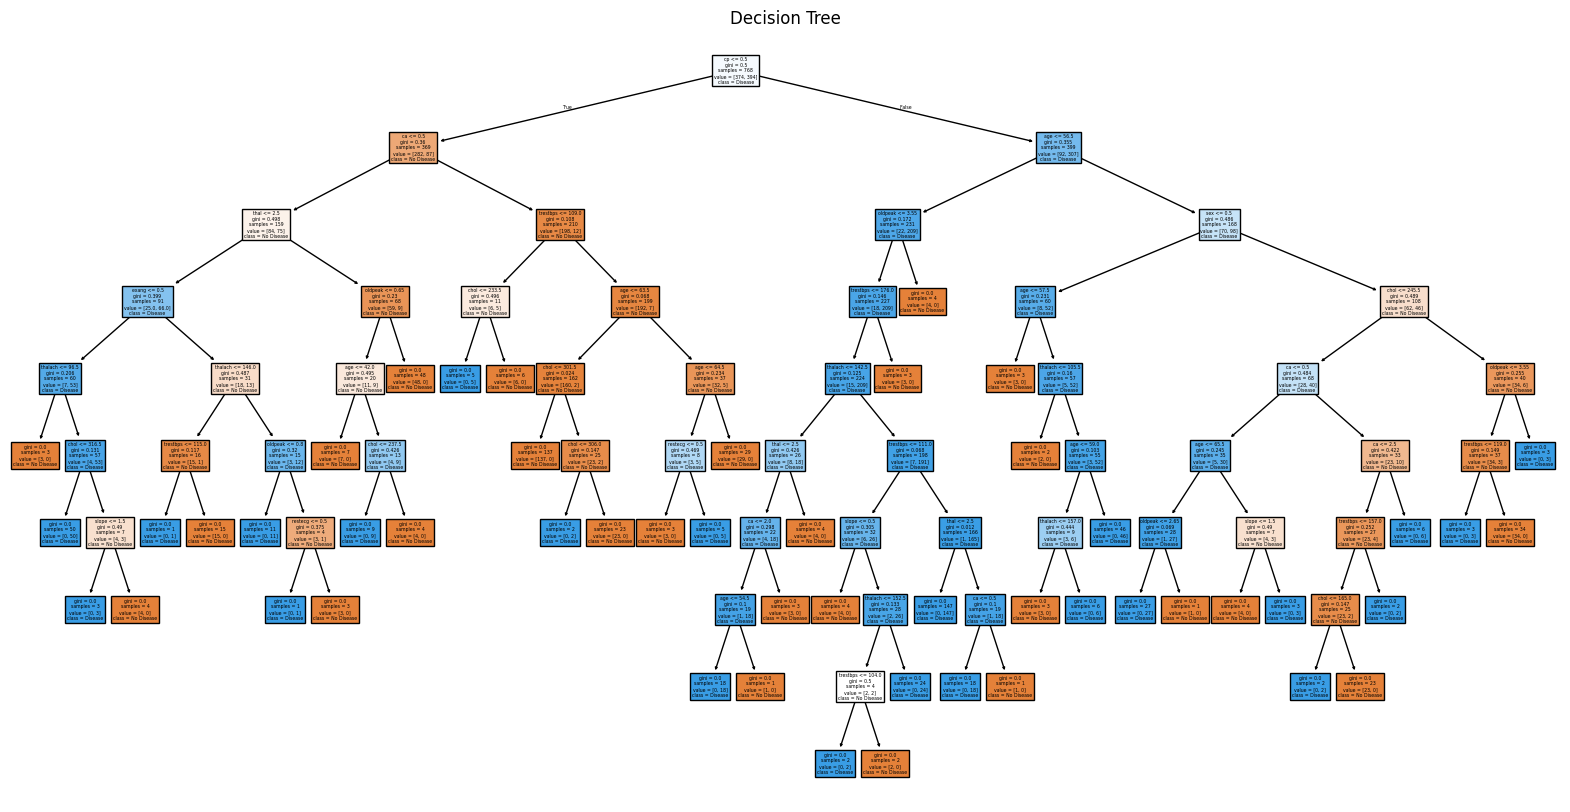

In [7]:
#Visualize the Decision tree
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True, feature_names=X.columns,class_names=['No Disease','Disease'])
plt.title("Decision Tree")
plt.show()

Analyse Overfitting and control tree depth

In [8]:
dt_new = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_new.fit(X_train, y_train)
print("Decision Tree  Train Accuracy:", dt_new.score(X_train, y_train))
print("Decision Tree Test Accuracy:", dt_new.score(X_test, y_test))


Decision Tree  Train Accuracy: 0.8828125
Decision Tree Test Accuracy: 0.8560311284046692


Train a random forest and comparing accuracy

In [9]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
print("Random forest accuracy on test set:",rf.score(X_test,y_test))

Random forest accuracy on test set: 1.0


Interpret feature importances

In [10]:
impt = rf.feature_importances_
feat_impt = pd.Series(impt,index=X.columns).sort_values(ascending=False)

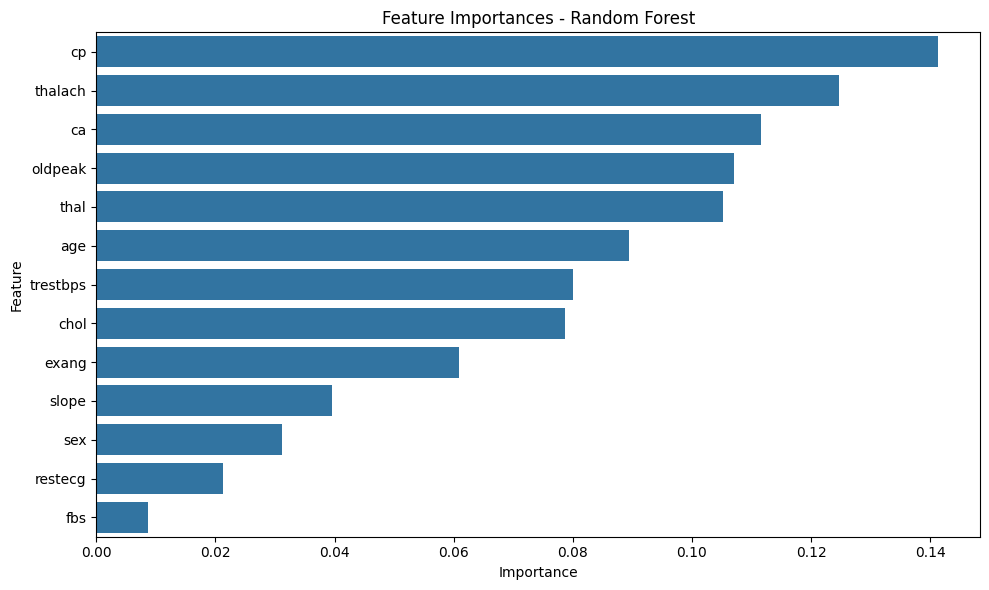

In [11]:
# PLotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_impt, y=feat_impt.index)
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Cross Validation Evaluation

In [12]:
cv_scores = cross_val_score(rf,X,y,cv=5)
print("Cross-Validation Scores:",cv_scores)
print("Mean CV Accuracy:",cv_scores.mean())

Cross-Validation Scores: [1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9970731707317073
